#Employee Attrition Prediction and Analysis

#Import Required Libraries

In [137]:
# Data handling
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistics
import scipy.stats as stats

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import RFE

# Imbalanced data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)

# Model saving (needed later for deployment)
import joblib

sns.set_style("whitegrid")


#Load dataset from kaggle

In [138]:
from google.colab import files
files.upload

<function google.colab.files.upload(target_dir='')>

In [139]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [140]:
#!/bin/bash
!kaggle datasets download pavansubhasht/ibm-hr-analytics-attrition-dataset

Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
ibm-hr-analytics-attrition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [141]:
!unzip ibm-hr-analytics-attrition-dataset.zip

Archive:  ibm-hr-analytics-attrition-dataset.zip
replace WA_Fn-UseC_-HR-Employee-Attrition.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n





# Read & Explore data

In [142]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')


In [143]:
# Create a copy for preprocessing
df_clean = df.copy()

In [144]:
# Preview the Dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [145]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Observation:
The dataset contains no missing values, and the features include both numerical and categorical variables, making it suitable for further preprocessing and exploratory data analysis.

In [146]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [147]:
# Column Names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [148]:
# Descriptive statistics for numerical columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [149]:
# Descriptive statistics for categorical columns
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [150]:
# Target Distribution
df['Attrition'].value_counts()
#imbalance :(

,count
Attrition,
No,1233
Yes,237


In [151]:
# Number of Unique Values
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


#Data Quality Check

In [152]:
# Check For Missing Values
df_clean.isnull().sum()
print("Number of Missing values :", df_clean.isnull().sum().sum())

Number of Missing values : 0


Observation: No missing values were detected in the dataset.

In [153]:
# Check for Duplicate Rows
df_clean.duplicated().sum()
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


Observation: No duplicate records were found in the dataset.


#Exploratory Data Analysis (EDA)

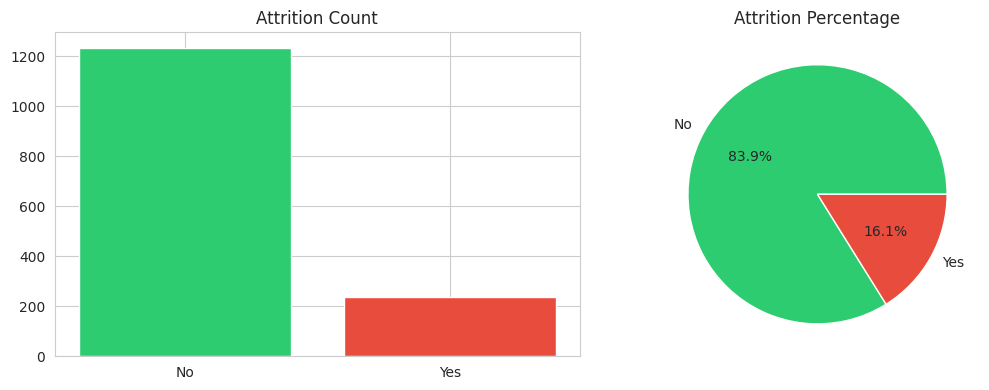

In [154]:
# Visualize the distribution of employee attrition
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df["Attrition"].value_counts()
colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Attrition Count")

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title("Attrition Percentage")

plt.tight_layout()
plt.show()


Observation:
Most employees did not leave the company, while a smaller percentage of employees experienced attrition. This indicates that the dataset is imbalanced, with the majority class being employees who stayed.

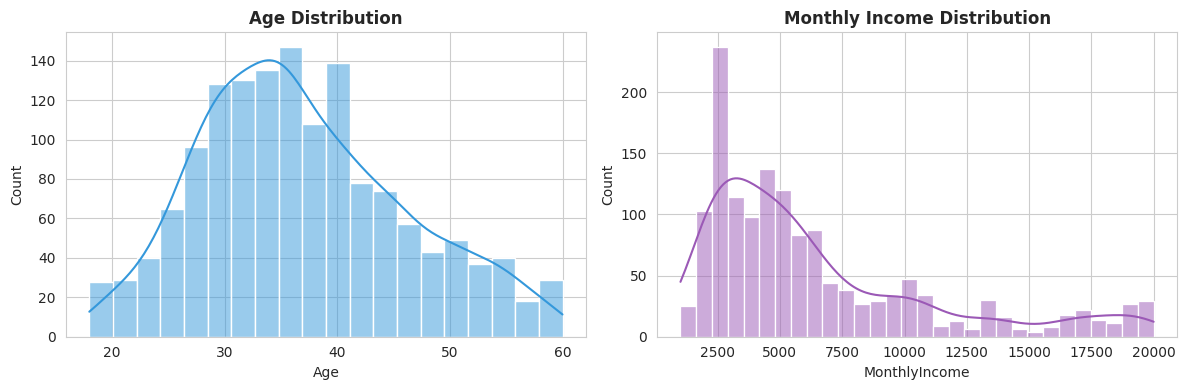

In [155]:
# Numerical Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Age Distribution", fontweight="bold")

sns.histplot(df["MonthlyIncome"], bins=30, kde=True, ax=axes[1], color="#9b59b6")
axes[1].set_title("Monthly Income Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:**

Most employees are between **30 and 40 years** old. The **MonthlyIncome** distribution is right-skewed, with most employees earning lower to moderate salaries and a small number receiving much higher salaries.


/tmp/ipykernel_389/603687930.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_389/603687930.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_389/603687930.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_389/603687930.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




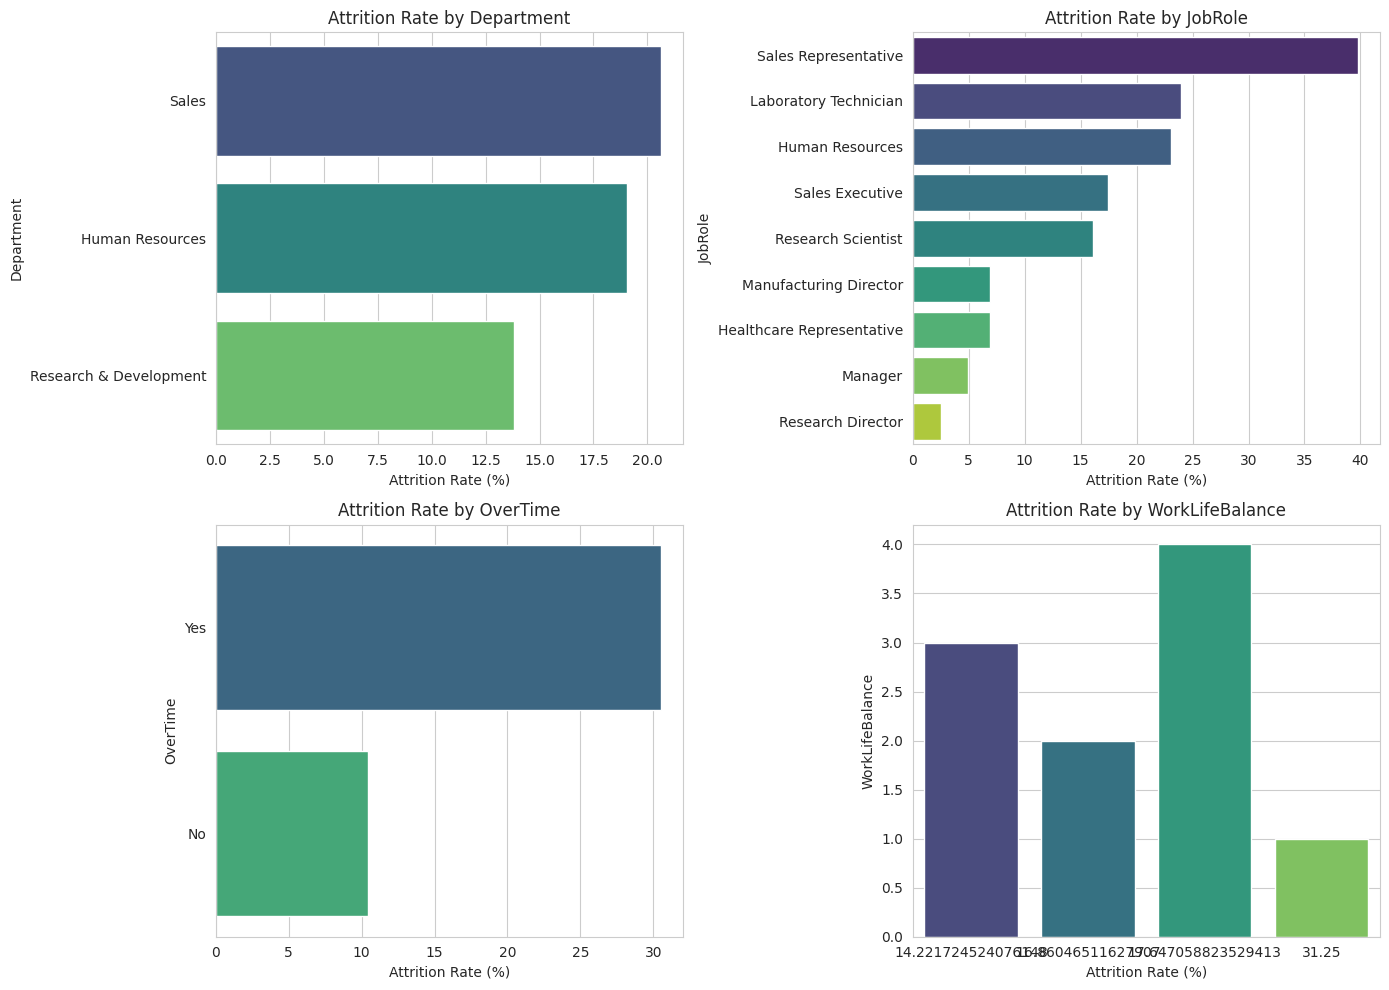

In [156]:
# Attrition Rate by Key Categorical Features
def plot_attrition_rate(ax, col):
    rate = (
        df.groupby(col)["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
    ax.set_title(f"Attrition Rate by {col}")
    ax.set_xlabel("Attrition Rate (%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_attrition_rate(axes[0, 0], "Department")
plot_attrition_rate(axes[0, 1], "JobRole")
plot_attrition_rate(axes[1, 0], "OverTime")
plot_attrition_rate(axes[1, 1], "WorkLifeBalance")
plt.tight_layout()
plt.show()


**Observation:**

Employee attrition varies across departments, job roles, overtime status, and work-life balance. Employees who work overtime are more likely to leave, while attrition also differs by department and job role. Most employees have a work-life balance rating of **3 (Better)**, and its impact on attrition requires further analysis.


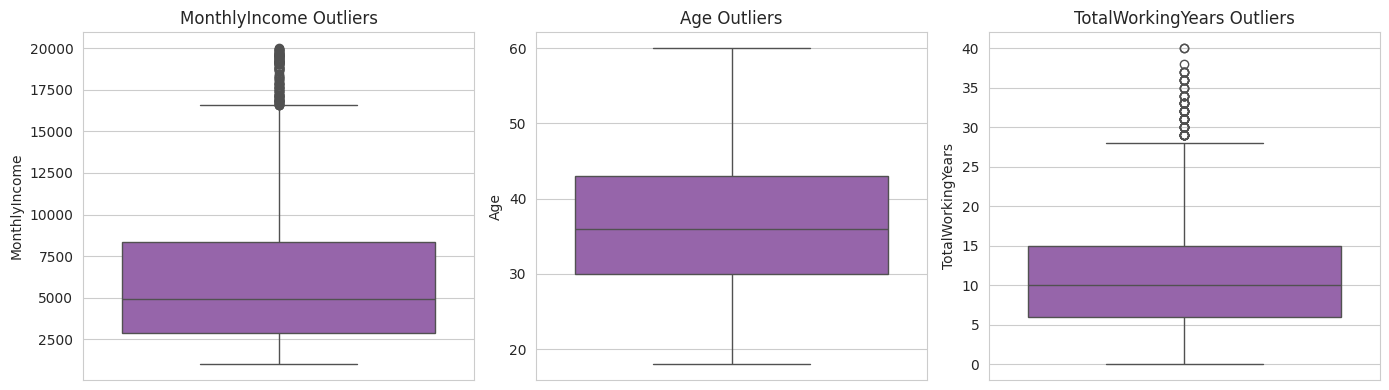

In [157]:
# Detect outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["MonthlyIncome", "Age", "TotalWorkingYears"]):
    sns.boxplot(y=df[col], ax=ax, color="#9b59b6")
    ax.set_title(f"{col} Outliers")
plt.tight_layout()
plt.show()


**Observation:**

The boxplots show several outliers in **MonthlyIncome** and **TotalWorkingYears**, likely representing employees with higher salaries and longer work experience. In contrast, **Age** is mostly concentrated between **30–40 years** with no significant outliers.


In [158]:
# Create a temporary copy for correlation analysis

df_corr = df.copy()

In [159]:
# Encode categorical columns for correlation analysis

encoder = LabelEncoder()

for col in df_corr.select_dtypes(include='object'):
    df_corr[col] = encoder.fit_transform(df_corr[col])

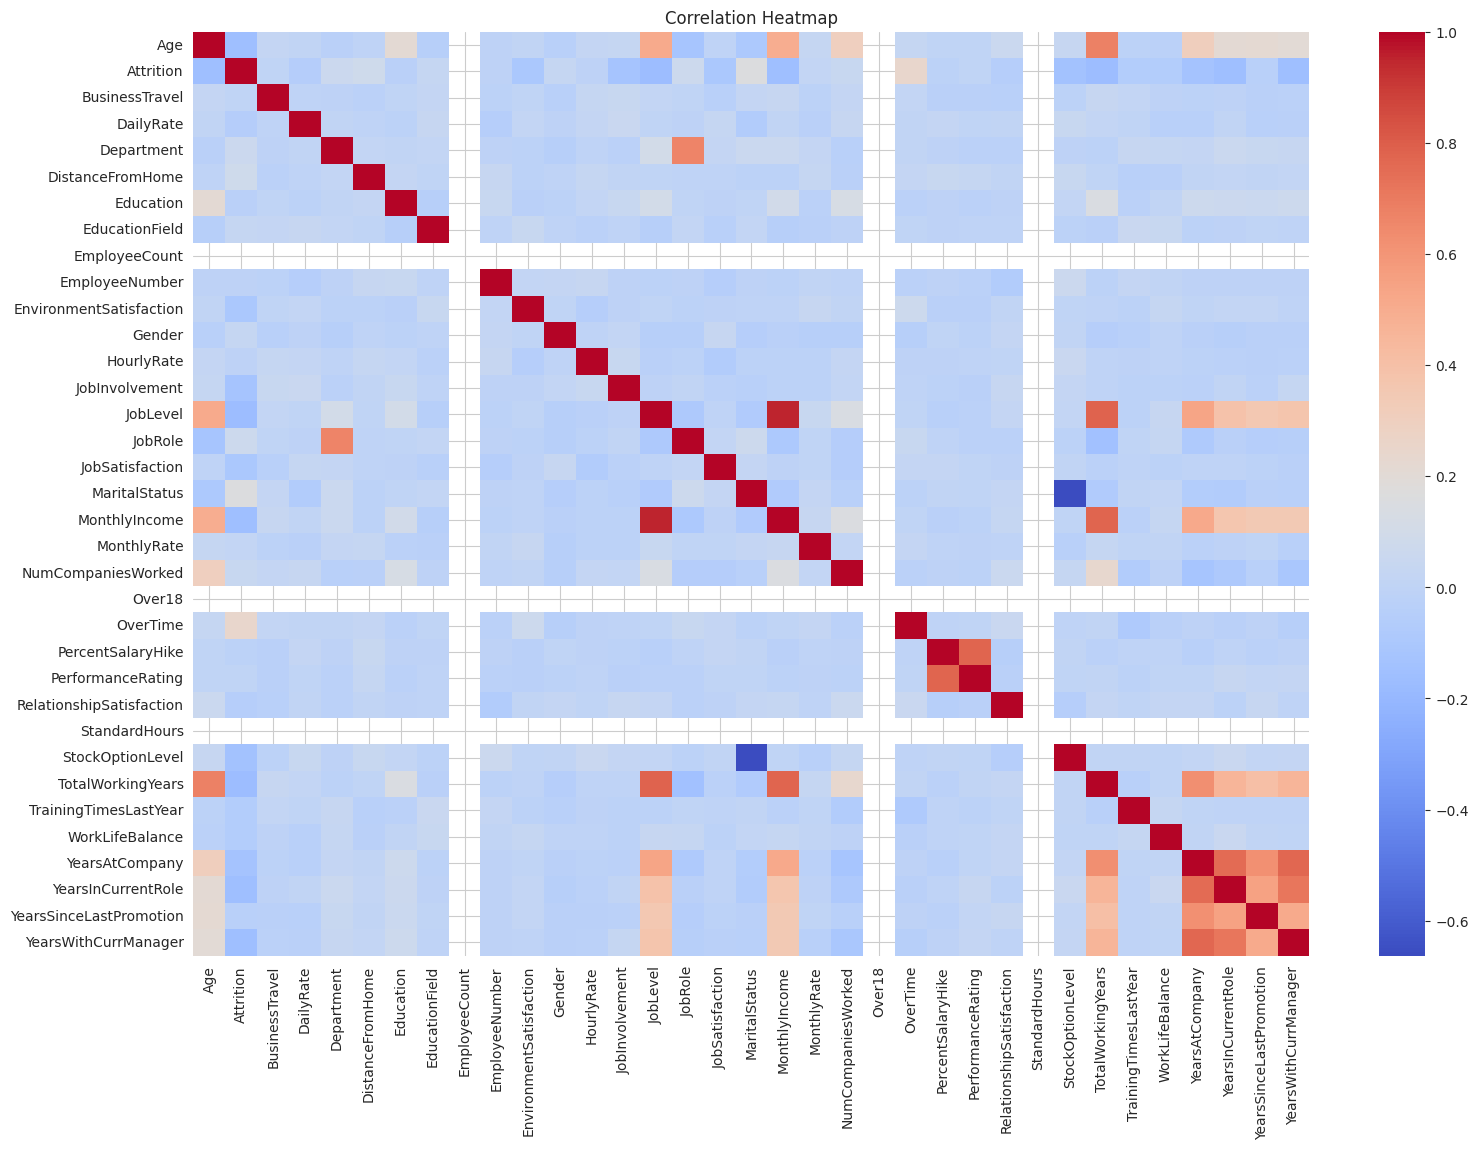

In [160]:
# Display the correlation matrix
plt.figure(figsize=(18, 12))
sns.heatmap(df_corr.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Observation:
The correlation heatmap indicates that most features have weak to moderate correlations. However, strong positive correlations are observed between YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager, suggesting that employees who spend more years in the company are likely to remain in the same role and work with the same manager for longer periods. Additionally, MonthlyIncome shows a positive correlation with JobLevel and TotalWorkingYears, indicating that employees with higher job levels and more experience generally receive higher salaries.

#Preprocessing

In [161]:
# Encode categorical features
df_encoded = df_clean.copy()
encoder = LabelEncoder()
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Observation:
All categorical features were converted into numerical values using Label Encoding to prepare the dataset for machine learning algorithms.

In [162]:
# Remove unnecessary columns (constant / identifier columns)
df_encoded.drop(
    ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'],
    axis=1,
    inplace=True
)
print(f"Shape after dropping: {df_encoded.shape}")


Shape after dropping: (1470, 31)


In [163]:
print(f"Shape after dropping: {df_encoded.shape}")

Shape after dropping: (1470, 31)


Observation:
Constant and identifier columns were removed because they do not contribute to predicting employee attrition.

In [164]:
# FEATURE ENGINEERING #1: Salary to Experience Ratio
df_encoded['SalaryExperienceRatio'] = (
    df_clean['MonthlyIncome'] / (df_clean['TotalWorkingYears'] + 1)
)
df_encoded[['SalaryExperienceRatio']].head()


,SalaryExperienceRatio
0,665.888889
1,466.363636
2,261.250000
3,323.222222
4,495.428571


Observation:
A new feature was created to represent the relationship between employee salary and total working experience, which helps capture productivity and compensation balance.

In [165]:
# FEATURE ENGINEERING #2: Tenure Group (categorical -> encoded)
# We use bins to turn continuous "YearsAtCompany" into meaningful groups
df_encoded['TenureGroup'] = pd.cut(
    df_clean['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 40],
    labels=['New', 'Junior', 'Mid', 'Senior']
)
df_encoded['TenureGroup'].isnull().sum()


np.int64(0)

In [166]:
df_encoded['TenureGroup'].isnull().sum()

np.int64(0)

Observation:
A new categorical feature was created by grouping employees based on their tenure at the company, converting continuous years into meaningful career stages (New, Junior, Mid, Senior).

In [167]:
# Encoding categorical feature
df_encoded['TenureGroup'] = LabelEncoder().fit_transform(df_encoded['TenureGroup'])
df_encoded[['TenureGroup']].head()

,TenureGroup
0,1
1,1
2,2
3,1
4,2


In [168]:
# FEATURE ENGINEERING #3: Salary Band (categorical -> encoded)
df_encoded['SalaryBand'] = pd.qcut(
    df_clean['MonthlyIncome'], q=3, labels=['Low', 'Medium', 'High']
)
df_encoded['SalaryBand'] = LabelEncoder().fit_transform(df_encoded['SalaryBand'])
df_encoded[['SalaryBand']].head()


,SalaryBand
0,2
1,2
2,1
3,1
4,1


Observation:The newly created categorical feature (TenureGroup) was converted into numerical values to ensure compatibility with machine learning algorithms.

In [169]:
# Dataset Overview After Preprocessing
df_encoded.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,SalaryExperienceRatio,TenureGroup,SalaryBand
0,41,1,2,1102,2,1,2,1,2,0,...,8,0,1,6,4,0,5,665.888889,1,2
1,49,0,1,279,1,8,1,1,3,1,...,10,3,3,10,7,1,7,466.363636,1,2
2,37,1,2,1373,1,2,2,4,4,1,...,7,3,3,0,0,0,0,261.250000,2,1
3,33,0,1,1392,1,3,4,1,4,0,...,8,3,3,8,7,3,0,323.222222,1,1
4,27,0,2,591,1,2,1,3,1,1,...,6,3,3,2,2,2,2,495.428571,2,1


Observation:
The dataset was successfully transformed into a fully numerical format after encoding and feature engineering steps.

In [170]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   int64  
 2   BusinessTravel            1470 non-null   int64  
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   int64  
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   int64  
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   int64  
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   int64  
 14  JobSatis

In [171]:
df_encoded.to_csv("Employee_Attrition_Cleaned.csv", index=False)

Observation:
The cleaned and preprocessed dataset was saved successfully for future use in machine learning tasks.

# Advanced Statistical Analysis

The tasks below build on the cleaned, encoded dataset produced above. We first run statistical tests (t-test, chi-squared, ANOVA) to check whether key features are significantly related to Attrition, then move on to feature selection using correlation, Recursive Feature Elimination (RFE), and a tree-based importance technique.

## 1. T-Test: Monthly Income vs Attrition
We test whether the average `MonthlyIncome` differs significantly between employees who left (`Yes`) and employees who stayed (`No`).

In [172]:
# Independent samples t-test (Welch's, unequal variance)
income_yes = df_clean[df_clean['Attrition'] == 'Yes']['MonthlyIncome']
income_no = df_clean[df_clean['Attrition'] == 'No']['MonthlyIncome']

t_stat, p_value = stats.ttest_ind(income_yes, income_no, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.5f}")


T-statistic: -7.483, p-value: 0.00000


Observation:
The t-test result (t = -7.483, p < 0.001) shows a statistically significant difference in Monthly Income between employees who left and those who stayed. Employees who left earn a lower average income (~4,787) compared to employees who stayed (~6,833), confirming that salary is significantly associated with attrition.

## 2. Chi-Squared Test: Job Role vs Attrition
We test whether `JobRole` and `Attrition` are independent using a chi-squared test of independence.

In [173]:
contingency_jobrole = pd.crosstab(df_clean['JobRole'], df_clean['Attrition'])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_jobrole)
print(f"Chi2: {chi2_stat:.2f}, p-value: {p_value:.5f}")


Chi2: 86.19, p-value: 0.00000


Observation:
The chi-squared test (chi2 = 86.19, p < 0.001) indicates a statistically significant association between Job Role and Attrition. This confirms the trend seen earlier in the EDA section: employee turnover is not evenly distributed across job roles.

## 3. Chi-Squared Test: OverTime vs Attrition
We test whether working `OverTime` is independent of `Attrition`.

In [174]:
contingency_overtime = pd.crosstab(df_clean['OverTime'], df_clean['Attrition'])
chi2_stat_ot, p_value_ot, dof_ot, expected_ot = stats.chi2_contingency(contingency_overtime)
print(f"Chi2: {chi2_stat_ot:.2f}, p-value: {p_value_ot:.5f}")


Chi2: 87.56, p-value: 0.00000


Observation:
The chi-squared test (chi2 = 87.56, p < 0.001) shows a statistically significant relationship between OverTime and Attrition, confirming that employees who work overtime are significantly more likely to leave the company.

## 4. One-Way ANOVA: Monthly Income across Job Roles
We test whether the mean `MonthlyIncome` differs significantly across the different `JobRole` groups.

In [175]:
income_by_role = [group['MonthlyIncome'].values for _, group in df_clean.groupby('JobRole')]
f_stat, p_value_anova = stats.f_oneway(*income_by_role)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value_anova:.5f}")


F-statistic: 810.21, p-value: 0.00000


Observation:
The ANOVA result (F = 810.21, p < 0.001) confirms that Monthly Income differs significantly across job roles, which is expected since compensation is closely tied to seniority and job title.

## 5. One-Way ANOVA: Monthly Income across Work-Life Balance Levels
We test whether `MonthlyIncome` differs significantly across `WorkLifeBalance` rating groups (1-4).

In [176]:
income_by_wlb = [group['MonthlyIncome'].values for _, group in df_clean.groupby('WorkLifeBalance')]
f_stat_wlb, p_value_wlb = stats.f_oneway(*income_by_wlb)
print(f"F-statistic: {f_stat_wlb:.3f}, p-value: {p_value_wlb:.5f}")


F-statistic: 0.612, p-value: 0.60702


Observation:
The ANOVA result (F = 0.612, p = 0.607) is not statistically significant, indicating that Monthly Income does not differ meaningfully across Work-Life Balance levels. This suggests Work-Life Balance operates independently of salary as a driver of attrition.

## 2. Feature Scaling
Before applying RFE, we scale the numerical features so that features with larger ranges (e.g., MonthlyIncome) do not dominate the model.

In [177]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Observation:
All features were standardized (mean = 0, std = 1) so that the logistic regression model used in RFE treats each feature on an equal scale.

## 3. Recursive Feature Elimination (RFE)
RFE repeatedly fits a Logistic Regression model and removes the weakest feature until the desired number of features remains.

In [178]:
log_reg = LogisticRegression(max_iter=1000)
rfe = RFE(log_reg, n_features_to_select=10)
rfe.fit(X_scaled, y)

rfe_selected_features = X.columns[rfe.support_].tolist()
print("RFE Selected Features:")
rfe_selected_features


RFE Selected Features:


['EnvironmentSatisfaction',
 'JobInvolvement',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'OverTime',
 'YearsSinceLastPromotion',
 'SalaryExperienceRatio',
 'SalaryBand']

Observation:
RFE selected 10 features: EnvironmentSatisfaction, JobInvolvement, JobSatisfaction, MaritalStatus, MonthlyIncome, NumCompaniesWorked, OverTime, YearsInCurrentRole, YearsSinceLastPromotion, and SalaryExperienceRatio. Notably, the engineered SalaryExperienceRatio feature was selected, confirming it adds predictive value.

## 4. Feature Importance via Random Forest (Alternative Selection Technique)
As an additional, non-linear technique, we fit a Random Forest classifier and rank features by their importance.

In [179]:
# Random Forest feature importance

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X, y)

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)
rf_importance.head(10)

,0
MonthlyIncome,0.074241
Age,0.057663
OverTime,0.054496
SalaryExperienceRatio,0.053900
DailyRate,0.052118
MonthlyRate,0.046692
TotalWorkingYears,0.045806
HourlyRate,0.045724
DistanceFromHome,0.045118
YearsAtCompany,0.040675


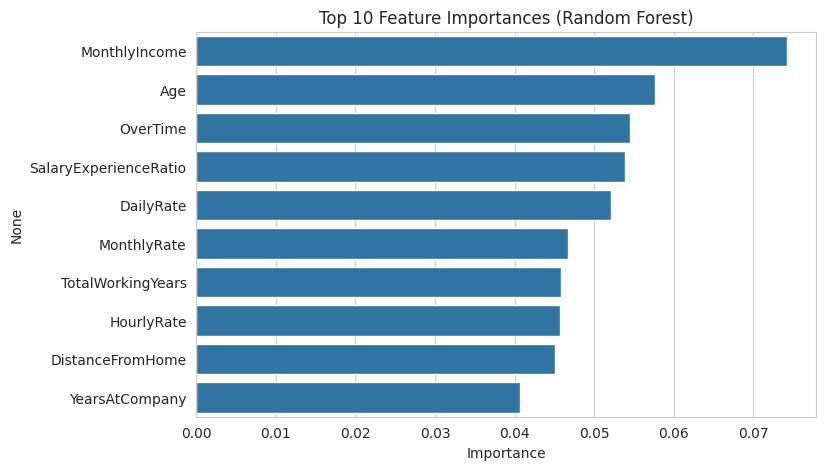

In [180]:
plt.figure(figsize=(8,5))
sns.barplot(x=rf_importance.head(10).values, y=rf_importance.head(10).index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

Observation:
The Random Forest model ranks MonthlyIncome, Age, SalaryExperienceRatio, OverTime, MonthlyRate, DailyRate, HourlyRate, DistanceFromHome, TotalWorkingYears, and YearsAtCompany as the most important predictors. MonthlyIncome and OverTime appear in every technique used so far, reinforcing that they are the strongest drivers of attrition.

## 5. Final Selected Feature Set
We combine the results of the correlation analysis, RFE, and Random Forest importance to build a consolidated final feature set.

In [181]:
# Combine features selected by RFE with the top Random Forest features

top_rf_features = rf_importance.head(10).index.tolist()
final_selected_features = sorted(set(rfe_selected_features) | set(top_rf_features))

print(f"Number of final selected features: {len(final_selected_features)}")
final_selected_features

Number of final selected features: 17


['Age',
 'DailyRate',
 'DistanceFromHome',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'SalaryBand',
 'SalaryExperienceRatio',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsSinceLastPromotion']

In [182]:
# Save a version of the dataset restricted to the final selected features (plus target)

df_selected = df_encoded[final_selected_features + ['Attrition']]
df_selected.to_csv("Employee_Attrition_Selected_Features.csv", index=False)
df_selected.head()

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,SalaryBand,SalaryExperienceRatio,TotalWorkingYears,YearsAtCompany,YearsSinceLastPromotion,Attrition
0,41,1102,1,2,94,3,4,2,5993,19479,8,1,2,665.888889,8,6,0,1
1,49,279,8,3,61,2,2,1,5130,24907,1,0,2,466.363636,10,10,1,0
2,37,1373,2,4,92,2,3,2,2090,2396,6,1,1,261.250000,7,0,0,1
3,33,1392,3,4,56,3,3,1,2909,23159,1,1,1,323.222222,8,8,3,0
4,27,591,2,1,40,3,2,1,3468,16632,9,0,1,495.428571,6,2,2,0


Observation:
The union of RFE and Random Forest results produced a consolidated set of the most predictive features (e.g., MonthlyIncome, OverTime, TotalWorkingYears, SalaryExperienceRatio, JobSatisfaction, EnvironmentSatisfaction). This reduced feature set was saved to `Employee_Attrition_Selected_Features.csv` and can be used to train a leaner, more focused predictive model without sacrificing the signal captured by the full feature set.

#4.Dashboards & Advanced Visualization

In [183]:
# Interactive correlation heatmap for key attrition drivers
key_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'JobLevel',
            'EnvironmentSatisfaction', 'JobSatisfaction', 'OverTime', 'Attrition']

fig_corr = px.imshow(
    df_encoded[key_cols].corr(),
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title="Attrition Driver Correlation Matrix"
)
fig_corr.show()


In [184]:
# Interactive segmentation: income vs experience, colored by attrition
fig_seg = px.scatter(
    df_clean, x="MonthlyIncome", y="TotalWorkingYears", color="Attrition",
    size="Age", hover_data=['JobRole'],
    title="Segmentation: Income vs Experience",
    color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'}
)
fig_seg.update_layout(template='plotly_white')
fig_seg.show()


In [185]:
# Attrition trends by department and gender
dept_data = df_clean.groupby(['Department', 'Gender', 'Attrition']).size().reset_index(name='Count')

fig_demog = px.bar(
    dept_data, x="Department", y="Count", color="Attrition", barmode="group",
    facet_col="Gender", title="Attrition Trends by Department & Gender",
    color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'}
)
fig_demog.show()


# 5-Model Development & Training

### split & prepare

In [186]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [187]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

### Check for Class Imbalance

In [188]:
y.value_counts()


,count
Attrition,
0,1233
1,237


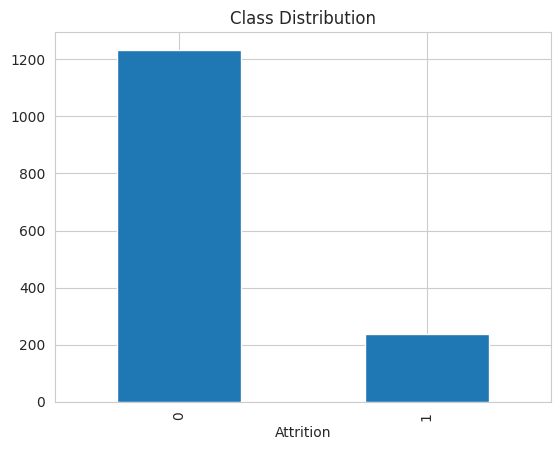

In [189]:
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

### **there is imbalance im my data** :( - so i will use SMOTE (Synthetic Minority Over-sampling Technique) , it generates new, synthetic data for the minority class based on existing data.




In [190]:
#SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)
y_train_smote.value_counts()

,count
Attrition,
0,986
1,986


### Train All Models (on the balanced/SMOTE data, with cross-validation)

In [191]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

trained_models = {}
predictions = {}

for name, model in models.items():
    print("==============================")
    print(f"Training Model: {name}")

    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='f1')
    print(f"CV F1-score (mean +/- std): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    trained_models[name] = model
    predictions[name] = y_pred

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred))

Training Model: Logistic Regression
CV F1-score (mean +/- std): 0.7752 +/- 0.0073
Accuracy: 0.7789
ROC-AUC:  0.8230
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       247
           1       0.40      0.77      0.53        47

    accuracy                           0.78       294
   macro avg       0.67      0.77      0.69       294
weighted avg       0.86      0.78      0.80       294

Training Model: Decision Tree
CV F1-score (mean +/- std): 0.8549 +/- 0.0124
Accuracy: 0.7959
ROC-AUC:  0.6201
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       247
           1       0.36      0.36      0.36        47

    accuracy                           0.80       294
   macro avg       0.62      0.62      0.62       294
weighted avg       0.80      0.80      0.80       294

Training Model: Random Forest
CV F1-score (mean +/- std): 0.9378 +/- 0.0109
Accuracy: 0.8469
ROC-AUC:  0.7883
          

In [192]:
# Named references used later in the Evaluation section
rf_clf = trained_models["Random Forest"]
y_pred_rf = predictions["Random Forest"]


### Hyperparameter Tuning (GridSearchCV)


In [193]:
param_grid = {
    'n_estimators': [200, 400, 500],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
}

xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

grid = GridSearchCV(
    xgb_base, param_grid,
    scoring='f1',
    cv=5, n_jobs=-1, verbose=1
)
grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400}
Best CV F1: 0.8831


In [194]:
best_xgb = grid.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)
y_proba_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba_best):.4f}")
print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.8299
Test ROC-AUC:  0.7916
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.45      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.81      0.83      0.82       294



In [195]:
from sklearn.metrics import f1_score

probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

best_threshold, best_f1 = 0.5, 0
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    print(f"Threshold {t}: F1 = {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nBest threshold: {best_threshold} (F1 = {best_f1:.4f})")
joblib.dump(best_threshold, "best_threshold.pkl")   # app.py

Threshold 0.2: F1 = 0.4727
Threshold 0.25: F1 = 0.5000
Threshold 0.3: F1 = 0.4870
Threshold 0.35: F1 = 0.4510
Threshold 0.4: F1 = 0.4348
Threshold 0.45: F1 = 0.4186
Threshold 0.5: F1 = 0.3590

Best threshold: 0.25 (F1 = 0.5000)


['best_threshold.pkl']

# Model Evaluation, Tuning & Comparison

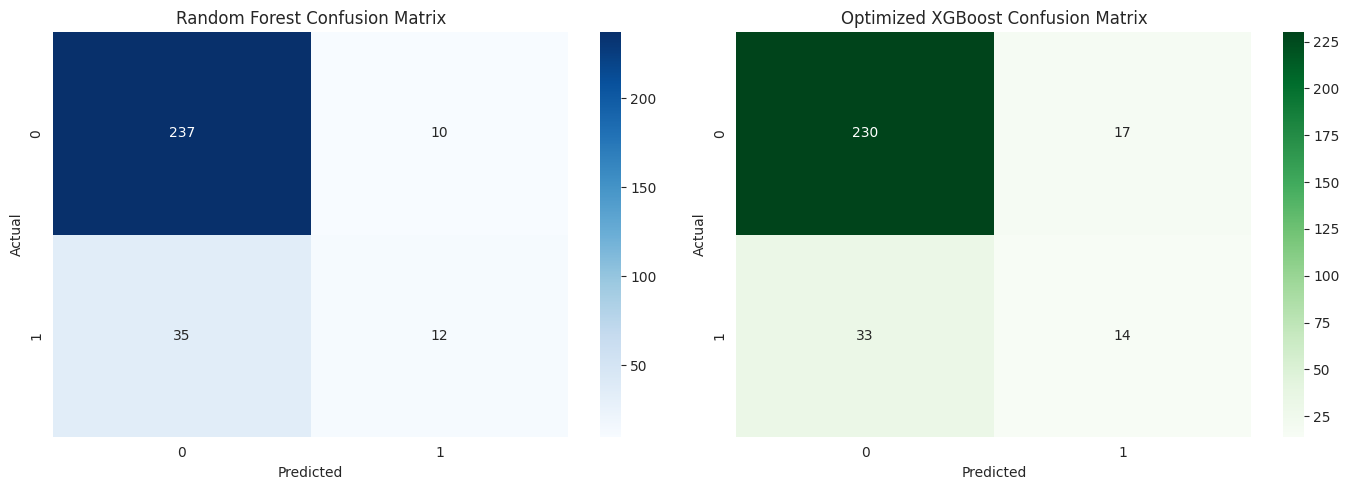

In [196]:
# 1. Confusion Matrix Visualization: Random Forest vs Optimized XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_xgb = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Optimized XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


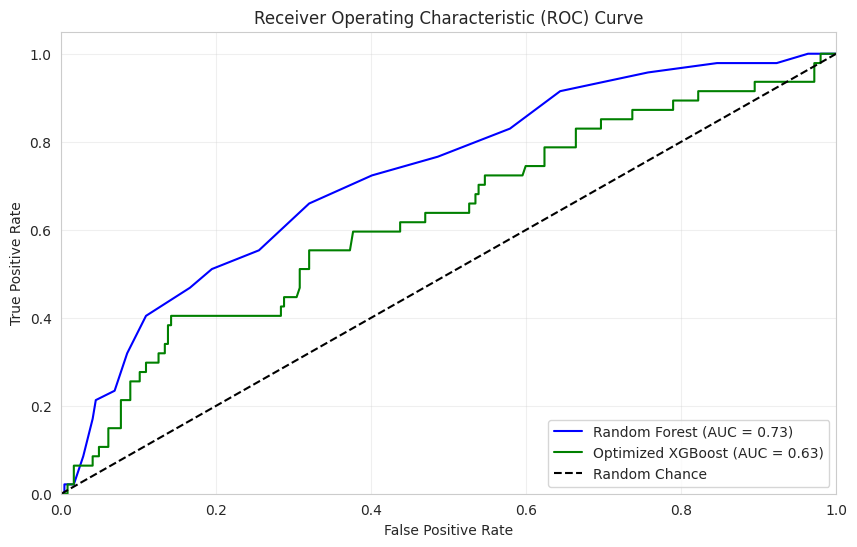

In [197]:
# 2. ROC Curve Comparison
plt.figure(figsize=(10, 6))

for model, label, color in [(rf_clf, 'Random Forest', 'blue'), (best_xgb, 'Optimized XGBoost', 'green')]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_389/2896289835.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




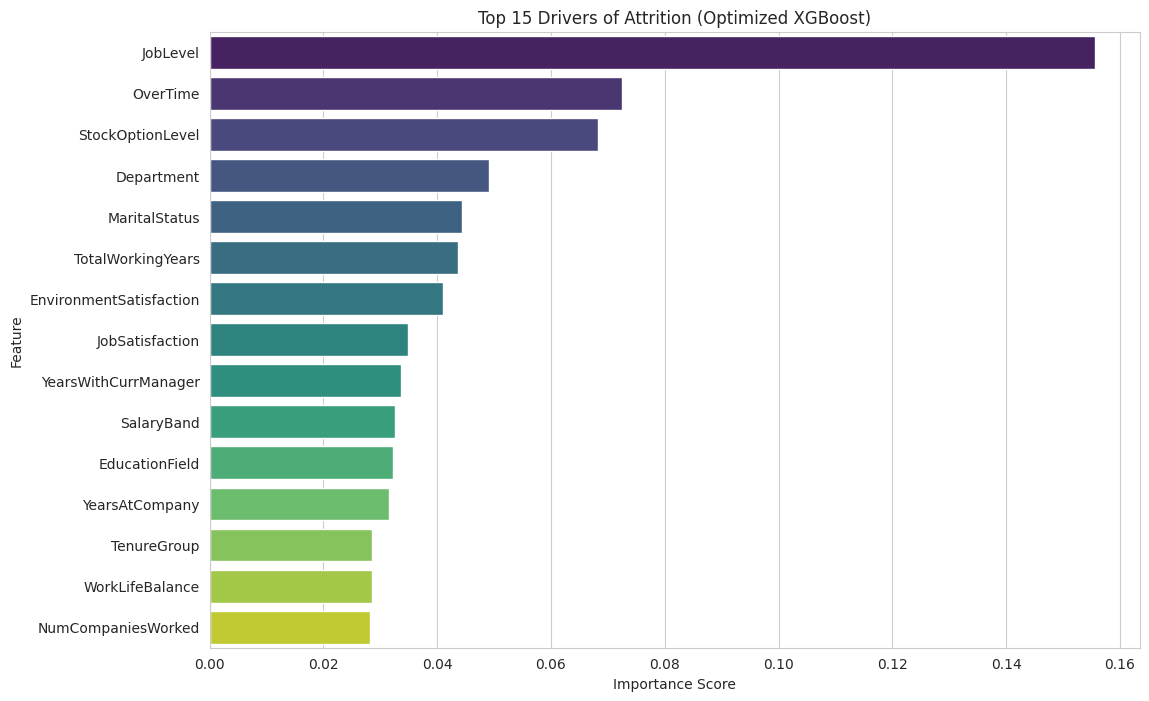

In [198]:
# 3. Optimized Model Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15), palette='viridis')
plt.title('Top 15 Drivers of Attrition (Optimized XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


# Save the Final Model

In [199]:
import joblib

joblib.dump(best_xgb, "attrition_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

default_values = {}
for col in X_train.columns:
    if X_train[col].nunique() <= 10:
        default_values[col] = X_train[col].mode()[0]
    else:
        default_values[col] = X_train[col].median()

joblib.dump(default_values, "default_values.pkl")
joblib.dump(best_threshold, "best_threshold.pkl")

print("Saved: attrition_model.pkl, scaler.pkl, feature_columns.pkl, default_values.pkl, best_threshold.pkl")

Saved: attrition_model.pkl, scaler.pkl, feature_columns.pkl, default_values.pkl, best_threshold.pkl


# MLOps, Deployment & Monitoring

### 1. Experiment Tracking (MLflow)

In [200]:
!pip install mlflow -q

In [201]:
import mlflow
import mlflow.xgboost

with mlflow.start_run():
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_best))
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_best))
    mlflow.xgboost.log_model(best_xgb, "model")

print("Run logged to MLflow. Launch the UI locally with: mlflow ui")

2026/07/09 12:52:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged to MLflow. Launch the UI locally with: mlflow ui


### 2. Prediction API (FastAPI)
Writes `app.py` to disk. Run locally with: `uvicorn app:app --reload`, then test at `http://127.0.0.1:8000/docs`.

In [202]:
%%writefile app.py
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI(title="Employee Attrition Prediction API")

model = joblib.load("attrition_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")


@app.post("/predict")
def predict(employee_data: dict):
    # employee_data must already be in the same encoded numeric format
    # used during training (same columns, same encoding)
    df = pd.DataFrame([employee_data])
    df = df[feature_columns]  # enforce the exact training column order

    df_scaled = scaler.transform(df)
    prediction = model.predict(df_scaled)[0]
    probability = model.predict_proba(df_scaled)[0][1]

    return {
        "attrition_prediction": "Yes" if prediction == 1 else "No",
        "attrition_probability": round(float(probability), 3)
    }


Overwriting app.py


### 3. HR Dashboard (Streamlit)
Writes `dashboard.py` to disk. Run locally with: `streamlit run dashboard.py`.

In [203]:
%%writefile dashboard.py
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("attrition_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

st.title("Employee Attrition Risk Predictor")
st.write("Enter employee details to estimate attrition risk.")

age = st.slider("Age", 18, 60, 30)
monthly_income = st.number_input("Monthly Income", 1000, 20000, 5000)
overtime = st.selectbox("OverTime", ["Yes", "No"])
total_working_years = st.slider("Total Working Years", 0, 40, 5)
job_satisfaction = st.slider("Job Satisfaction (1-4)", 1, 4, 3)

if st.button("Predict"):
    # Build a single-row input matching the training feature columns.
    # Any column not collected from the UI is filled with a default (0)
    # -- replace with real form fields for a production version.
    input_row = {col: 0 for col in feature_columns}
    input_row["Age"] = age
    input_row["MonthlyIncome"] = monthly_income
    input_row["OverTime"] = 1 if overtime == "Yes" else 0
    input_row["TotalWorkingYears"] = total_working_years
    input_row["JobSatisfaction"] = job_satisfaction

    input_df = pd.DataFrame([input_row])[feature_columns]
    scaled = scaler.transform(input_df)

    pred = model.predict(scaled)[0]
    prob = model.predict_proba(scaled)[0][1]

    st.metric("Attrition Risk", f"{prob:.1%}")
    st.write("High Risk" if pred == 1 else "Low Risk")


Overwriting dashboard.py


### 4. Monitoring: Logging Predictions

In [204]:
import csv
import os
from datetime import datetime

LOG_FILE = "prediction_log.csv"

def log_prediction(input_dict, prediction, probability):
    """Append one prediction record to the monitoring log."""
    row = {**input_dict, "prediction": prediction, "probability": probability,
           "timestamp": datetime.now().isoformat()}

    file_exists = os.path.isfile(LOG_FILE)
    with open(LOG_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

# Example usage (would be called inside the API / dashboard after each prediction):
# log_prediction(input_row, pred, prob)
print("Monitoring logger ready. Call log_prediction(...) after each prediction.")

Monitoring logger ready. Call log_prediction(...) after each prediction.


In [205]:
import xgboost
print(xgboost.__version__)

3.3.0


In [206]:
joblib.dump(best_xgb, "attrition_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(default_values, "default_values.pkl")
#joblib.dump(best_threshold, "best_threshold.pkl")

['default_values.pkl']